<div style="display:flex; align-items:center;">
    <h1>shmoopy</h1>
    <img src="_static/images/shmoo_flipped.png" alt="shmoo" style="max-width:80px; padding-left:20px;">
</div>

Obscured from the modern memory by the incessant, boisterous onslaught of the Marvel Cinematic and DC Extended Universes, is another 1940s comic book hero, conceived with the primary objective of fulfilling all of humanity's wants and needs:  Al Capp's "The Shmoo".   

Though most have forgotten this plump, bowling-pin-shaped embodiement of generosity that tastes like chicken when broiled, a small fellowship of devoted scientists and engineers have endeavoured to keep the memory of "the shmoo" alive via the "shmoo plot", a way to visualize a system's performance over a range of operating conditions.  `shmoopy` honors those efforts by providing *a simple tool for iterating through (or "shmooing") multiple tunable variables in order to identify a system's best settings*. 



## Components of a shmoo

A shmoo experiment requires three things:

1. a csv file of "tunable" parameters (or knobs) to test for some system (VALIDATION??)
2. a custom python class with a "shmoo" method that performs all the steps to run the system under test with each set of tunable parameters
3. "metric" methods that perform various calculations on the results of the system for later analysis

### CSV file

The csv file is where tunable parameters for an experiment are defined.  Each row in the table represents a specific test condition in an overall test plan.  However, `shmoopy` makes the process of generating all permutations of multivariate tunable parameters easy with some syntax magic.  This means a user can define multiple test cases from within single cell in a single table row.  For example, consider the following csv file with only 1 row:

<div style="font-family: 'Courier New', Courier, monospace;">
tunableA,tunableB,tunableC<br>
A B C,1:5:5,\$tunableB\$
</div>

This will be expanded by `shmoopy` to run the following:

<div style="font-family: 'Courier New', Courier, monospace;">
tunableA,tunableB,tunableC<br>
A,1,1<br>
A,2,2<br>
A,3,3<br>
A,4,4<br>
A,5,5<br>
B,1,1<br>
B,2,2<br>
B,3,3<br>
B,4,4<br>
B,5,5<br>
C,1,1<br>
C,2,2<br>
C,3,3<br>
C,4,4<br>
C,5,5<br>
</div>

*For a more detailed explanation of cell syntax see the full docs.*

### Shmoo class

The shmoo class is where the user defines the system under test.  In other words, all steps that are specific to your experiment and define what occurs based on the unique set of tunables defined in the csv are handled in this class.  A few notes about the shmoo class:

1. The shmoo class can contain anything you want, but at minimum must include the main execution function (called `run` by default)

Your `run` function must accept the following input parameters and always returns a dictonary
```
    def run(self, irow, row) -> Dict[str, Any]:
```
`irow` is the current row number of the csv table.  `row` is a `NamedTuple` that contains all of the tunable parameters in the current row, defined using the "." style (i.e., `row.tunableA`)

2. To minimize the chance of a crash in a long experiment, `shmoopy` allows you to validate your tunable parameters before launching the shmoo.  Within your shmoo class you can create methods with the names of your tunable parameters (same as the column headers in the csv) and you can use special decorators to declare things like valid ranges, valid lists of values, etc.  If your table contains errors, `shmoopy` will raise an exception before beginning the test.

Consider an image processing task with a tunable called **saturation** that can range from -8 to 8.  The following method in your shmoo class will validate your table value makes sense before launching.  As defined here, it will also provide a default value of 0 if this tunable is not defined in the csv.

```
    @tunable_range(-8, 8)
    def intensity(self, value=0):
        """
        Used in Reinhard algorithm; result intensity in [-8, 8] range. Greater intensity produces brighter results.
        """
        return value
```

3. Any other methods or attributes you need for your experiment are allowed and can be defined normally within your shmoo class

### Metrics

A shmoo is only useful if it computes something (or many somethings) for a given test case.  This is handled within the shmoo class by defining specific calculation methods with the `@metric` decorator.  All metric methods (unless manually skipped, see docs for more details) will run for each row and the computed value or values are added as new columns in the csv table.  When the shmoo completes, you are given a table where each row has the test conditions used and the metrics that were computed.

In order for the metric function to have access to data from the `run` method, it is required that the `run` function `return locals()` (i.e., every variable defined within the `run` function) and accept a dictionary input.  The metric function must then return any calculations as a dictionary and `shmoopy` automatically adds these new values to the output table.

For example, assume our shmoo class is doing some kind of image processing and we want to compute stats on the output image.  This can be achieved by adding the following method to the shmoo class:

```
    @metric
    def stats(self, values: Dict[str, Any]) -> Dict[str, float]:
        """
        Calculate image statistics for the LDR output
        """
        return {
            'mean': np.mean(values['image_output']),
            'std': np.std(values['image_output']),
            'min': np.min(values['image_output']),
            'max': np.max(values['image_output'])
        }

```

## Example

In [1]:
import os, cv2
import shmoopy
import fivecentplots as fcp  # for visualization
from shmoopy.examples.tonemap import ToneMapShmoo

Assume we have the following single-row csv of tunables for tone mapping of an high-dynamic range image:

In [2]:
pd.read_csv(Path(shmoopy.__file__).parent / 'examples/tonemap/gamma_only.csv')

,algorithm,gamma,image_src
0,drago reinhard mantiuk,1 2 3,examples/tonemap/cobblestone_street_night_1k.hdr


This is a simple sweep of the gamma parameter for 3 different tonemap methods.  When `shmoopy` builds the test plan, both the `algorithm` and the `gamma` cell values are expanded and we end up with 9 different test cases:

In [3]:
shmoopy.create_test_plan(Path(shmoopy.__file__).parent / 'examples/tonemap/gamma_only.csv')

,algorithm,gamma,image_src
0,drago,1,examples/tonemap/cobblestone_street_night_1k.hdr
1,drago,2,examples/tonemap/cobblestone_street_night_1k.hdr
2,drago,3,examples/tonemap/cobblestone_street_night_1k.hdr
3,reinhard,1,examples/tonemap/cobblestone_street_night_1k.hdr
4,reinhard,2,examples/tonemap/cobblestone_street_night_1k.hdr
5,reinhard,3,examples/tonemap/cobblestone_street_night_1k.hdr
6,mantiuk,1,examples/tonemap/cobblestone_street_night_1k.hdr
7,mantiuk,2,examples/tonemap/cobblestone_street_night_1k.hdr
8,mantiuk,3,examples/tonemap/cobblestone_street_night_1k.hdr


We can make an instance of our example shmoo class and run the shmoo as follows:

In [4]:
tms = ToneMapShmoo(save_images=True)  # save_images is option in this shmoo class to save the tonemapped images
results = shmoopy.launch(tms, Path(shmoopy.__file__).parent / 'examples/tonemap/gamma_only.csv')
results[['algorithm', 'gamma', 'mean', 'std', 'min', 'max']]

,algorithm,gamma,mean,std,min,max
0,drago,1,0.510871,2.550844,0,254
1,drago,2,10.357991,9.492322,0,254
2,drago,3,28.429036,16.433928,0,255
3,reinhard,1,147.935432,53.223176,0,255
4,reinhard,2,190.343056,37.814174,0,255
5,reinhard,3,208.684807,28.777816,0,255
6,mantiuk,1,0.001757,0.395329,0,255
7,mantiuk,2,1.995637,1.105584,0,255
8,mantiuk,3,11.378160,2.998954,0,255


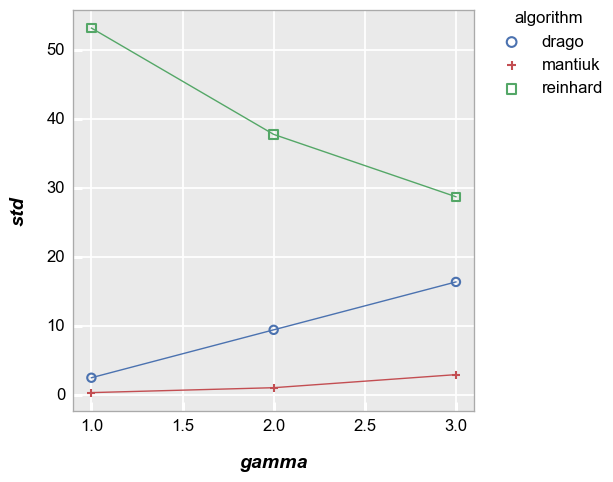

In [5]:
fcp.plot(results, x='gamma', y='std', legend='algorithm')

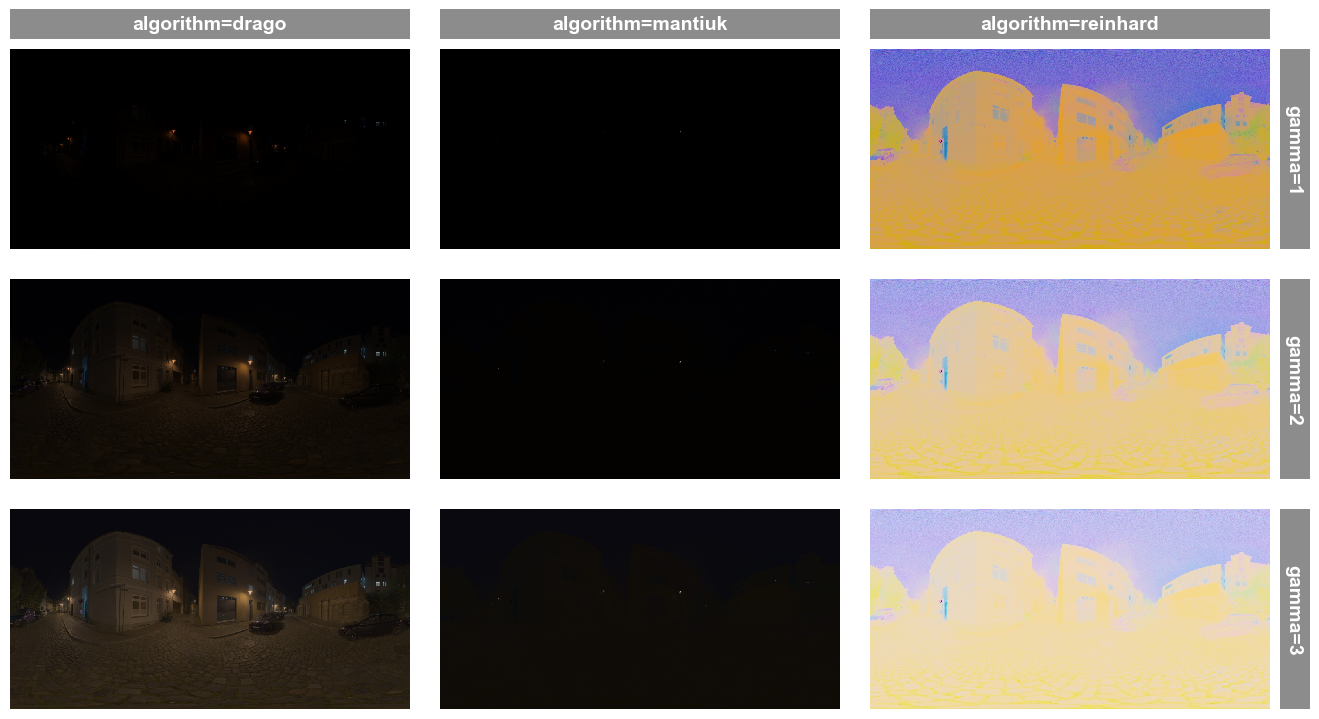

In [6]:
img_dir = 'results_' + str(results['uuid'].iloc[0])
imgs = {}
for irow, row in results.iterrows():
    img_path = os.path.join(img_dir, f'output_{irow}.jpg')
    imgs[irow] = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
fcp.imshow(results, imgs=imgs, col='algorithm', row='gamma', share_z=False)